# Stability Breeds Instability — a quantitative teardown 🔬
### Prolonged low vol vs forward drawdowns · HAC and non-overlapping · GARCH and FIGARCH mean-reversion nulls

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The companion to the [notebook for the curious](01_for_the_curious.ipynb). The study turns on
**§4**: the real slope of forward drawdown on prolonged calm, set against the distribution
the same regression produces on tapes simulated from no-feedback volatility models fitted to
the same 92 years. Volatility mean reversion is the confound, and in those models it pushes
the slope **negative** — so the bar is not zero, it is the null.

> **Beat 0 · Verdict (real tape)** — numbers sourced to [`docs/results.md`](../docs/results.md),
> as-of 2018-11-30, fingerprint `394be76d78ac`. The executed cells recompute them from the
> frozen tapes; the synthetic controls in §8 are labelled as such and never feed a stamp.
>
> ⚠️ **Not investment advice.** Fama-French `Mkt-RF + RF` is a **total** return; the S&P 500
> tape (§6) is a **price** index; the VIX tape (§7) is five years and used as an anecdote.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
warnings.filterwarnings("ignore")
from calm import data, strategy as st
ff = data.load_ff()
r, rf = ff["mkt"], ff["rf"]
sig = st.calm_signal(r)
print(f"Fama-French monthly TOTAL return, {ff.index[0].date()} -> {ff.index[-1].date()} "
      f"(as-of {data.AS_OF}), fingerprint {data.fingerprint(ff)}")

Fama-French monthly TOTAL return, 1926-07-31 -> 2018-11-30 (as-of 2018-11-30), fingerprint 394be76d78ac


## Verdict, up front

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** | Weak | primary slope +1.4% per SD of calm on the 24-month max drawdown, HAC t = 0.88 (non-overlap 0.75, ~37 windows); no-feedback null mean −1.3%; one-sided p = **0.08** (GARCH-t), **0.06** (FIGARCH-t); halves −0.9% / +3.9%; 7 independent ≥20% drawdowns |
| **Tradability** | Mirage | calm de-risk net excess Sharpe 0.487 vs 0.496 buy-and-hold (Δ −0.008, block-bootstrap p(Δ≤0) = 0.60); vol-target 0.455; max DD −46% vs −50% |

> 💡 **In plain words.** The tape leans Minsky's way and a no-feedback world leans the other
> way, but the gap is a 1-in-13-to-1-in-17 event under the null, not 1-in-20 — and the trade
> loses Sharpe.

## 1 · Hypotheses (pre-registered)

- **H₁ (primary).** The slope of the 24-month forward max drawdown on the standardised
  prolonged-calm score is positive with HAC t ≥ 2.
- **H₂ (the confound).** That slope exceeds the slope produced by a GARCH(1,1)-t **and** a
  FIGARCH-t fitted to the same tape, one-sided p < 0.05 each.
- **H₃ (two horizons).** Low vol now predicts low vol next month (clustering, AR(1) > 0), while
  prolonged calm predicts *more* vol and drawdown at 1-3 years.
- **H₄ (trade).** Halving equity after prolonged calm beats buy-and-hold on net excess Sharpe
  (block-bootstrap p < 0.05) with a shallower drawdown, and beats a plain vol-target.

The verdict rule (`strategy.verdict`) encodes H₁+H₂ → Real, a raw-only or p < 0.10 result → Weak,
H₄ → Investable; it is unit-tested in both directions.

## 2 · The signal

`rv_t` = std of the last 12 monthly total returns × √12; `trend_t` = trailing 120-month mean of
`rv`; `low_t = max(−log(rv_t/trend_t), 0)`; `calm_t` = trailing 60-month mean of `low`. All
past-only: `calm_t` is known at the close of month t, and the first reading needs 189 months
of history (first value 1942-04).

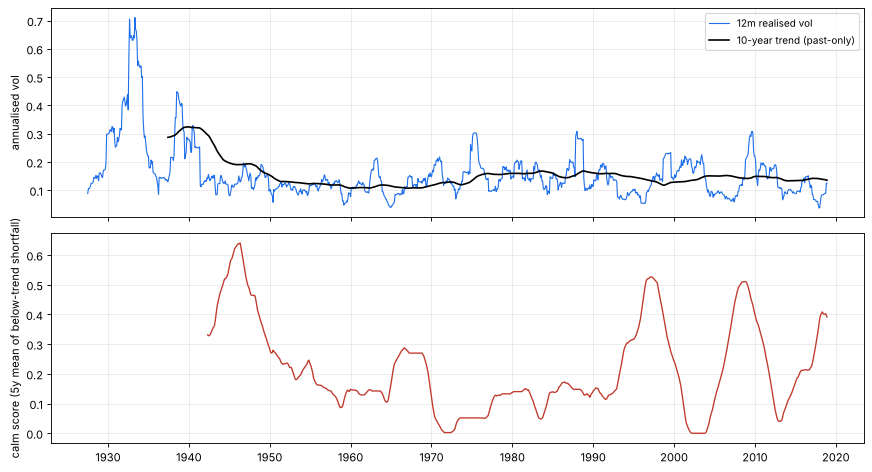

count   920.0000
mean      0.2150
std       0.1500
min       0.0000
25%       0.1260
50%       0.1610
75%       0.2910
max       0.6410


In [2]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(sig["rv"], color="#1f6feb", lw=1, label="12m realised vol")
ax[0].plot(sig["trend"], color="k", lw=1.5, label="10-year trend (past-only)")
ax[0].legend(fontsize=9); ax[0].set_ylabel("annualised vol")
ax[1].plot(sig["calm"], color="#c0392b", lw=1.2)
ax[1].set_ylabel("calm score (5y mean of below-trend shortfall)")
plt.tight_layout(); plt.show()
print(sig["calm"].describe().round(3).to_string())

## 3 · Every horizon, every outcome

Slope per 1 SD of calm, Newey-West with 2H lags; the non-overlapping t keeps every H-th month
(median across offsets).

 H outcome   slope   t_hac  t_nonoverlap   n  n_indep  mean_y
 1     mdd  0.0002  0.1551        0.2085 919      919  0.0118
 1   crash -0.0005 -0.9934       -0.9990 919      919  0.0011
 1     vol  0.0038  0.9190        1.2024 919      919  0.1174
 1     ret  0.0015  0.8336        1.0074 919      919  0.0062
 3     mdd  0.0008  0.2437        0.2713 917      305  0.0339
 3   crash  0.0023  0.3704        0.7600 917      305  0.0098
 3     vol  0.0037  0.8463        0.9094 917      305  0.1343
 3     ret  0.0045  0.8519        0.8981 917      305  0.0186
12     mdd  0.0073  0.6770        0.5955 908       75  0.0931
12   crash  0.0089  0.2438        0.2050 908       75  0.1046
12     vol  0.0065  1.2050        1.2313 908       75  0.1420
12     ret  0.0159  0.8233        0.6912 908       75  0.0726
24     mdd  0.0141  0.8780        0.7468 896       37  0.1409
24   crash  0.0278  0.5062        0.4203 896       37  0.2154
24     vol  0.0084  1.4984        1.3670 896       37  0.1444
24     r

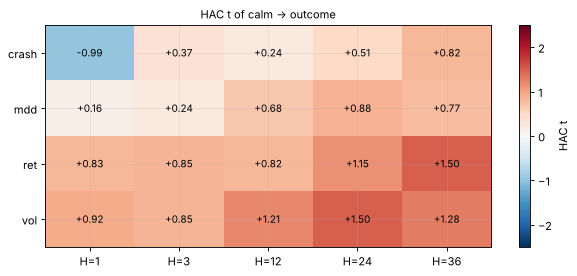

In [3]:
tab = st.horizon_table(r, rf)
print(tab.round(4).to_string(index=False))
piv = tab.pivot(index="outcome", columns="H", values="t_hac")
fig, ax = plt.subplots(figsize=(9, 3.6))
im = ax.imshow(piv.to_numpy(), cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"H={h}" for h in piv.columns])
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.iat[i, j]:+.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="HAC t"); ax.set_title("HAC t of calm -> outcome", fontsize=10)
plt.show()

> 💡 **In plain words.** Every long-horizon sign points Minsky's way and none clears 2. The
> primary cell (24-month drawdown) has t = 0.88; thinning to ~37 non-overlapping
> windows gives 0.75 — HAC is not hiding anything.

## 4 · The confound — mean reversion, simulated

Both models are fitted (constant mean, Student-t) to the real monthly excess returns, simulated
at the real length with the real bill path added back, and the identical 24-month regression is
run on every path. p is one-sided in Minsky's direction.

GARCH  : {'mu': 0.947, 'omega': 0.956, 'alpha[1]': 0.136, 'beta[1]': 0.83, 'nu': 7.926}
FIGARCH: {'mu': 0.931, 'omega': 0.841, 'phi': 0.043, 'd': 0.765, 'beta': 0.693, 'nu': 7.435}
     null outcome   real  null_mean     q05    q95      p
  GARCH-t     mdd 0.0141    -0.0135 -0.0437 0.0169 0.0773
  GARCH-t   crash 0.0278    -0.0398 -0.1415 0.0724 0.1571
  GARCH-t     vol 0.0084    -0.0115 -0.0377 0.0103 0.0673
  GARCH-t     ret 0.0321     0.0081 -0.0548 0.0726 0.2668
FIGARCH-t     mdd 0.0141    -0.0325 -0.0928 0.0149 0.0574
FIGARCH-t   crash 0.0278    -0.0605 -0.1937 0.0513 0.0998
FIGARCH-t     vol 0.0084    -0.0479 -0.1459 0.0073 0.0449
FIGARCH-t     ret 0.0321     0.0724 -0.0721 0.3607 0.4414


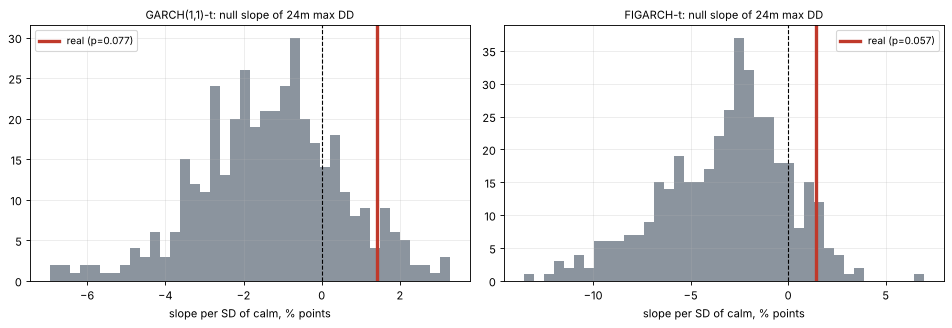

In [4]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res_g = st.fit_vol_model(ff["mkt_rf"], "garch")
    res_f = st.fit_vol_model(ff["mkt_rf"], "figarch")
    NG = st.mean_reversion_null(ff, "garch", 24, 400, seed=1021, res=res_g)
    NF = st.mean_reversion_null(ff, "figarch", 24, 400, seed=1021, res=res_f)
print("GARCH  :", {k: round(v, 3) for k, v in NG["params"].items()})
print("FIGARCH:", {k: round(v, 3) for k, v in NF["params"].items()})
rows = []
for name, N in (("GARCH-t", NG), ("FIGARCH-t", NF)):
    for o in st.OUTCOMES:
        q = N[o]
        rows.append({"null": name, "outcome": o, "real": q["real"], "null_mean": q["null_mean"],
                     "q05": q["null_q05"], "q95": q["null_q95"], "p": q["p_value"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (name, N) in zip(axs, (("GARCH(1,1)-t", NG), ("FIGARCH-t", NF))):
    x = N["_null_samples"]["mdd"]
    x = x[np.isfinite(x)]
    ax.hist(x * 100, bins=40, color="#8b949e")
    ax.axvline(N["mdd"]["real"] * 100, color="#c0392b", lw=3, label=f"real (p={N['mdd']['p_value']:.3f})")
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.set_title(f"{name}: null slope of 24m max DD", fontsize=10)
    ax.set_xlabel("slope per SD of calm, % points"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> 💡 **In plain words.** With no feedback, calm is followed by *calmer* (null mean −1.3%):
> GARCH persistence means a quiet market stays quiet for a while. So mean reversion does not
> manufacture the Minsky slope here — it works *against* it, which makes the real positive slope
> more interesting, not less. It still lands at p = 0.08 / 0.06: the right tail, not
> past the 5% line. The FIGARCH null is wider (long memory makes the slow component wander),
> and the two agree.

## 5 · Robustness — signal definition and sample halves

The pre-registered point is (120, 60). The grid is shown, not chosen.

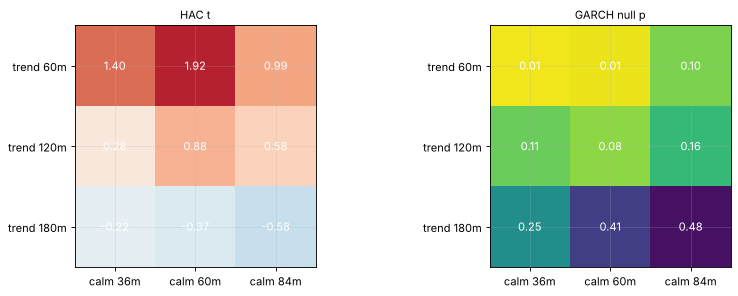

half 1942-04-30 -> 1979-07-31: slope -0.0088  HAC t -0.49
half 1979-08-31 -> 2016-11-30: slope +0.0394  HAC t +1.58


In [5]:
grid = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fo24 = st.forward_outcomes(r, rf, 24)
    for tw in (60, 120, 180):
        for cw in (36, 60, 84):
            win = {"trend_window": tw, "calm_window": cw}
            rr = st.predictive_regression(st.calm_signal(r, **win)["calm"], fo24["mdd"], 24)
            m_ = st.mean_reversion_null(ff, "garch", 24, 200, seed=7, res=res_g, windows=win)
            grid.append({"trend": tw, "calm": cw, "t": rr["t"], "p": m_["mdd"]["p_value"]})
G = pd.DataFrame(grid)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, cmap, lim in ((axs[0], "t", "RdBu_r", (-2.5, 2.5)), (axs[1], "p", "viridis_r", (0, 0.5))):
    P = G.pivot(index="trend", columns="calm", values=col)
    im = ax.imshow(P.to_numpy(), cmap=cmap, vmin=lim[0], vmax=lim[1])
    ax.set_xticks(range(3)); ax.set_xticklabels([f"calm {c}m" for c in P.columns])
    ax.set_yticks(range(3)); ax.set_yticklabels([f"trend {t}m" for t in P.index])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{P.iat[i, j]:.2f}", ha="center", va="center", color="w")
    ax.set_title("HAC t" if col == "t" else "GARCH null p", fontsize=10)
plt.tight_layout(); plt.show()
for x in st.half_sample_slopes(r, rf):
    print(f"half {x['start']} -> {x['end']}: slope {x['slope']:+.4f}  HAC t {x['t']:+.2f}")

> 💡 **In plain words.** Measure "calm" against a 5-year norm and the case strengthens
> (p ≈ 0.01); against a 15-year norm it vanishes, even flips. The registered 10-year version sits
> in between. And the whole effect lives after 1979 (+3.9% per SD) — before that it points the
> other way (−0.9%). A result that depends this much on the ruler and the decade is the
> definition of Weak.

## 6 · Two horizons — clustering vs the Minsky claim

The short-horizon sign on the daily S&P 500 (price index; monthly realised vol from daily
returns), then the full horizon profile on Fama-French with a GARCH null band.

S&P 500 1990-2022, log monthly RV AR(1): phi = 0.688 (HAC t 14.6), half-life 1.9 months, n = 394


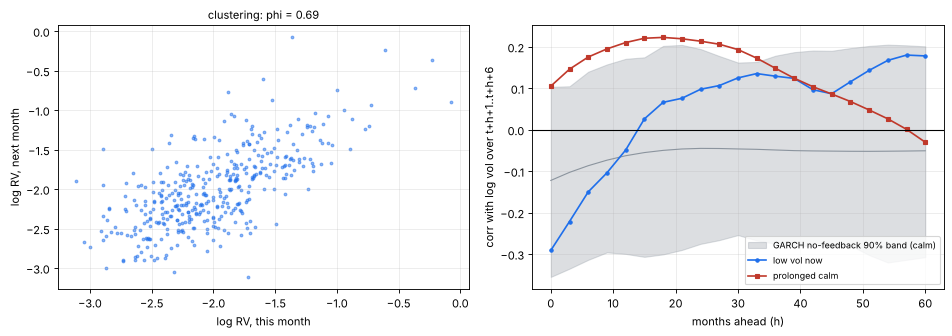

In [6]:
spx = data.load_spx_daily()
rvm = data.monthly_rv_from_daily(spx)
ar = st.clustering_ar1(rvm)
print(f"S&P 500 1990-2022, log monthly RV AR(1): phi = {ar['phi']:.3f} (HAC t {ar['t']:.1f}), "
      f"half-life {ar['half_life_months']:.1f} months, n = {ar['n']}")
prof_now = st.vol_horizon_profile(r, -sig["dev"])
prof_calm = st.vol_horizon_profile(r, sig["calm"])
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    band = st.null_horizon_profile(res_g, "garch", ff, n_paths=60)
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
y = np.log(rvm)
axs[0].scatter(y.shift(1), y, s=6, alpha=0.5, color="#1f6feb")
axs[0].set_xlabel("log RV, this month"); axs[0].set_ylabel("log RV, next month")
axs[0].set_title(f"clustering: phi = {ar['phi']:.2f}", fontsize=10)
axs[1].fill_between(band.index, band["q05"], band["q95"], color="#8b949e", alpha=0.3,
                    label="GARCH no-feedback 90% band (calm)")
axs[1].plot(band.index, band["mean"], color="#8b949e", lw=1)
axs[1].plot(prof_now["h"], prof_now["corr"], "o-", color="#1f6feb", ms=3, label="low vol now")
axs[1].plot(prof_calm["h"], prof_calm["corr"], "s-", color="#c0392b", ms=3, label="prolonged calm")
axs[1].axhline(0, color="k", lw=1); axs[1].set_xlabel("months ahead (h)")
axs[1].set_ylabel("corr with log vol over t+h+1..t+h+6"); axs[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

> 💡 **In plain words.** Short horizon: calm now → calm next month, φ = 0.69, t = 14.6.
> No debate. Long horizon: prolonged calm → *more* vol one to three years out, and the red curve
> pokes above the null's pointwise band for a long stretch. It is the strongest-looking picture
> in the study — and it is a post-hoc scan of 21 overlapping horizons against a 60-path band,
> so it moves the stamp nowhere. Pre-registering "calm → 24-month forward vol, correlation
> null" is the obvious fork (beat 7).

## 7 · Illustrations — not inference

The post-1990 S&P tape only produces a calm score from late 2005; the VIX tape is five years.

             calm  next 24m max DD (price)
date                                      
2006-12-31 0.3880                   0.4220
2007-06-30 0.4690                   0.5260
2014-06-30 0.1300                   0.0890
2017-12-31 0.4030                   0.1400
2019-12-31 0.3270                   0.2000


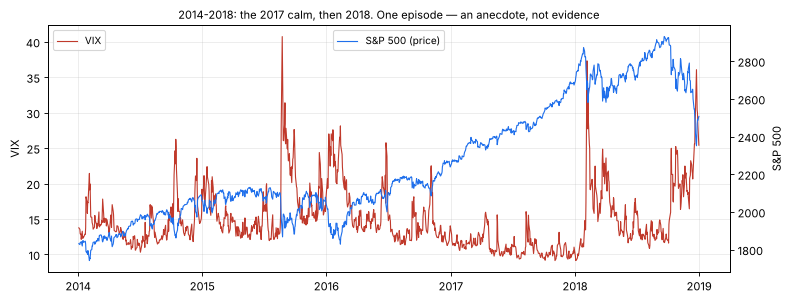

VIX 2017 mean 11.1, below 11 on 54% of days; 2018 max 37.3


In [7]:
mret = data.monthly_returns_from_daily(spx)
s3 = st.calm_signal(mret)["calm"]
fo3 = st.forward_outcomes(mret, None, 24)
print(pd.DataFrame({"calm": s3, "next 24m max DD (price)": fo3["mdd"]}).loc[
    ["2006-12-31", "2007-06-30", "2014-06-30", "2017-12-31", "2019-12-31"]].round(3).to_string())
vix = data.load_vix()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vix.index, vix, color="#c0392b", lw=1, label="VIX")
ax2 = ax.twinx()
s = spx.loc[vix.index[0]:vix.index[-1]]
ax2.plot(s.index, s, color="#1f6feb", lw=1, label="S&P 500 (price)")
ax.set_ylabel("VIX"); ax2.set_ylabel("S&P 500")
ax.set_title("2014-2018: the 2017 calm, then 2018. One episode — an anecdote, not evidence",
             fontsize=10)
ax.legend(loc="upper left", fontsize=9); ax2.legend(loc="upper center", fontsize=9)
ax2.grid(False); plt.show()
v17 = vix[vix.index.year == 2017]
print(f"VIX 2017 mean {v17.mean():.1f}, below 11 on {(v17 < 11).mean():.0%} of days; "
      f"2018 max {vix[vix.index.year == 2018].max():.1f}")

> 💡 **In plain words.** 2007 and 2017 are the two calm peaks every believer cites, and both were
> followed by a fall. They are two observations. The 92-year tape in §3-§5 is where the
> inference lives.

## 8 · Machinery proof — the synthetic controls (not market evidence)

Two synthetic worlds from `data.synthetic_monthly`: same GARCH, same crash rate; in one a
crash is likelier after prolonged calm (`signal_strength=1`), in the other crashes are blind to
it (`0`). The harness must fire on the first and stay quiet on the second.

In [8]:
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for s_ in (1.0, 0.0):
        f, tr = data.synthetic_monthly(signal_strength=s_, seed=1021)
        c_ = st.calm_signal(f["mkt"])["calm"]
        fo_ = st.forward_outcomes(f["mkt"], f["rf"], 24)
        rr = st.predictive_regression(c_, fo_["mdd"], 24)
        m_ = st.mean_reversion_null(f, "garch", 24, 200, seed=5)
        rows.append({"world": "planted" if s_ else "null", "crashes": tr["n_crashes"],
                     "slope": rr["slope"], "HAC t": rr["t"],
                     "GARCH null mean": m_["mdd"]["null_mean"], "p": m_["mdd"]["p_value"]})
print("SYNTHETIC — machinery proof only")
print(pd.DataFrame(rows).round(4).to_string(index=False))

SYNTHETIC — machinery proof only
  world  crashes   slope   HAC t  GARCH null mean      p
planted      119  0.0351  2.2222          -0.0203 0.0050
   null      124 -0.0282 -1.6434          -0.0268 0.5373


> 💡 **In plain words.** When the feedback is there, the harness finds it (p well under 0.05);
> when it isn't, the null comparison says so, even though both worlds have the same number of
> crashes. So the real tape's p ≈ 0.06-0.08 is a statement about the market, not a blind spot
> in the method.

## 9 · Could you trade it?

Weights decided at the close of month t, held through t+1 (one shift); turnover one-way × NAV
from the drifted weight; 10 bp one-way; cash earns bills; Sharpe on excess-of-bills for every leg.

             sharpe_gross  sharpe_net  cagr_net    vol  max_dd  terminal  turnover_yr  avg_weight
buy_hold           0.4960      0.4960    0.1090 0.1470 -0.5040  985.5230       0.0000      1.0000
calm_derisk        0.4880      0.4870    0.1040 0.1360 -0.4640  716.5140       0.0550      0.9200
vol_target         0.4570      0.4550    0.0970 0.1300 -0.4440  473.6970       0.2620      0.9070


calm_derisk  - buy&hold: dSharpe -0.008  95% CI [-0.067, +0.063]  p(<=0) 0.60


vol_target   - buy&hold: dSharpe -0.041  95% CI [-0.091, +0.005]  p(<=0) 0.96
 cost_bps  sharpe_rule  sharpe_bh    diff
        0       0.4876     0.4955 -0.0079
       10       0.4872     0.4955 -0.0083
       25       0.4866     0.4955 -0.0090
       50       0.4856     0.4955 -0.0100


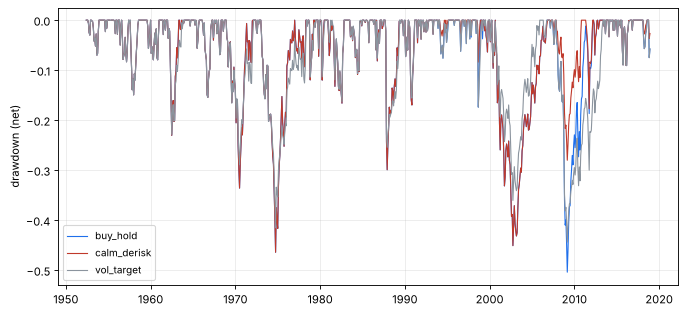

de-risked 16% of months; market excess then 7.9%/yr, otherwise 7.2%/yr


In [9]:
W = {k: st.rule_weights(r, k) for k in ("buy_hold", "calm_derisk", "vol_target")}
start = max(W["calm_derisk"].first_valid_index(), W["vol_target"].first_valid_index())
ffb = ff.loc[start:]
BT = {k: st.backtest(ffb, w.loc[start:], 10.0) for k, w in W.items()}
S = pd.DataFrame({k: st.summary(b) for k, b in BT.items()}).T
print(S[["sharpe_gross", "sharpe_net", "cagr_net", "vol", "max_dd", "terminal",
         "turnover_yr", "avg_weight"]].astype(float).round(3).to_string())
ex = {k: b["net"] - b["rf"] for k, b in BT.items()}
for k in ("calm_derisk", "vol_target"):
    b = st.sharpe_diff_bootstrap(ex[k], ex["buy_hold"])
    print(f"{k:12s} - buy&hold: dSharpe {b['diff']:+.3f}  95% CI [{b['ci'][0]:+.3f}, "
          f"{b['ci'][1]:+.3f}]  p(<=0) {b['p_le_zero']:.2f}")
print(st.cost_sweep(ffb, W["calm_derisk"].loc[start:]).round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 4.5))
for k, col in (("buy_hold", "#1f6feb"), ("calm_derisk", "#c0392b"), ("vol_target", "#8b949e")):
    w_ = (1 + BT[k]["net"]).cumprod()
    ax.plot(w_ / w_.cummax() - 1, color=col, lw=1, label=k)
ax.set_ylabel("drawdown (net)"); ax.legend(fontsize=9); plt.show()
w = BT["calm_derisk"]["w"]
mex = (ffb["mkt"] - ffb["rf"]).reindex(w.index)
print(f"de-risked {(w < 1).mean():.0%} of months; market excess then {mex[w < 1].mean()*12:.1%}/yr, "
      f"otherwise {mex[w >= 1].mean()*12:.1%}/yr")

> 💡 **In plain words.** The rule trades about once every twenty years' worth of NAV — costs are
> irrelevant. It loses on *timing*: it was de-risked 16% of the time, and the
> market earned **more** in those calm months than in the rest. Shallower drawdown
> (−46% vs −50%), lower Sharpe (0.487 vs 0.496), less money. A plain
> vol-target, which reacts to vol that is high *now*, did no better here on a monthly tape. **Mirage.**

## 10 · Going further

- **Pre-register the vol leg.** Calm → 24-month forward realised vol, scored by correlation
  against a no-feedback null, on a tape that was not used to find it (international indices,
  or daily data pre-1990).
- **Crises, not crashes.** Danielsson, Valenzuela & Zer predict banking crises across 60
  countries; joining a cross-country crisis chronology to this harness would test the claim as
  written.
- **A harsher null.** A Markov-switching volatility model has a fatter slow component than
  FIGARCH; if the real slope stops beating it, the case weakens further.
- **The ruler matters.** §5 shows the result hinges on the trend window. A fork that chose it
  out-of-sample (e.g. by expanding-window cross-validation) would remove a researcher degree of
  freedom this study only reports.